# redMaPPer $\times$ Compton-y for $0.4<z<0.6$

This notebook runs the same compensated TreeCorr `DK-RK` estimator as the earlier simulation/data comparison, changing only the strict redshift selection to $0.4<z<0.6$. The richness cut remains $\lambda>20$, the catalog `z` column is used, and the previous $0.5<z<0.8$ products are not overwritten.

In [1]:
%matplotlib inline
import json
import platform
import sys
import time
from pathlib import Path

import h5py
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import treecorr

HERE = Path.cwd()
if HERE.name != 'DES_cluster':
    HERE = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/DES_cluster')
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))
import redmapper_y_cross as cross

CONFIG = HERE / 'params_redmapper_y_cross_z0p4_0p6.yaml'
plt.rcParams.update({'figure.dpi': 105, 'savefig.dpi': 170})
print({'python': platform.python_version(), 'numpy': np.__version__, 'matplotlib': matplotlib.__version__, 'treecorr': treecorr.__version__, 'config': str(CONFIG)})

{'python': '3.10.16', 'numpy': '1.26.4', 'matplotlib': '3.9.3', 'treecorr': '4.3.3', 'config': '/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/DES_cluster/params_redmapper_y_cross_z0p4_0p6.yaml'}


## Execute the measurement

The simulation uses the inclusive first-octant footprint and receives one 1.6-arcmin Gaussian smoothing. The ACT map is used as supplied. Random catalogs are sampled deterministically in nested 5x, 10x, and 20x subsets; 20x is the hard cap, not an externally proven convergence plateau.

{
  "claim_boundary": "diagnostic only; ACT BUNIT/beam metadata absent; no fitted amplitude or goodness claim",
  "comparison_png": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_sim_data_comparison_z0p4_0p6.png",
  "data_central_mean": 5.919983793614895e-07,
  "data_clusters": 4674,
  "data_null_pte": 0.8269368451182312,
  "data_random_ratio": 10,
  "data_resolution": {
    "control_downsample_factor": 2,
    "max_shift_sigma": 0.559654036764165,
    "median_shift_sigma": 0.056251637254882574,
    "pass": false,
    "science_downsample_factor": 1
  },
  "diagnostics_png": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_selection_random_diagnostics_z0p4_0p6.png",
  "elapsed_seconds": 489.4228997139726,
  "input_hashes_unchanged": true,
  "result_hdf5": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_sim_data_comparison_z0p4_0p6.h5",
  "simulation_central_mean":

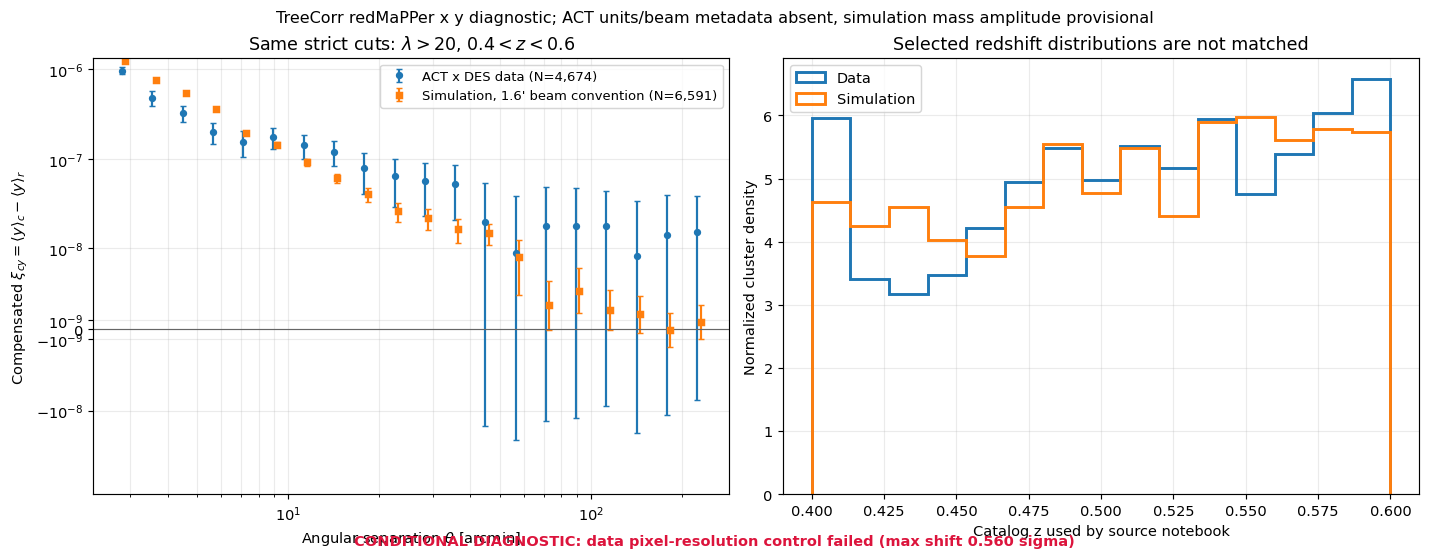

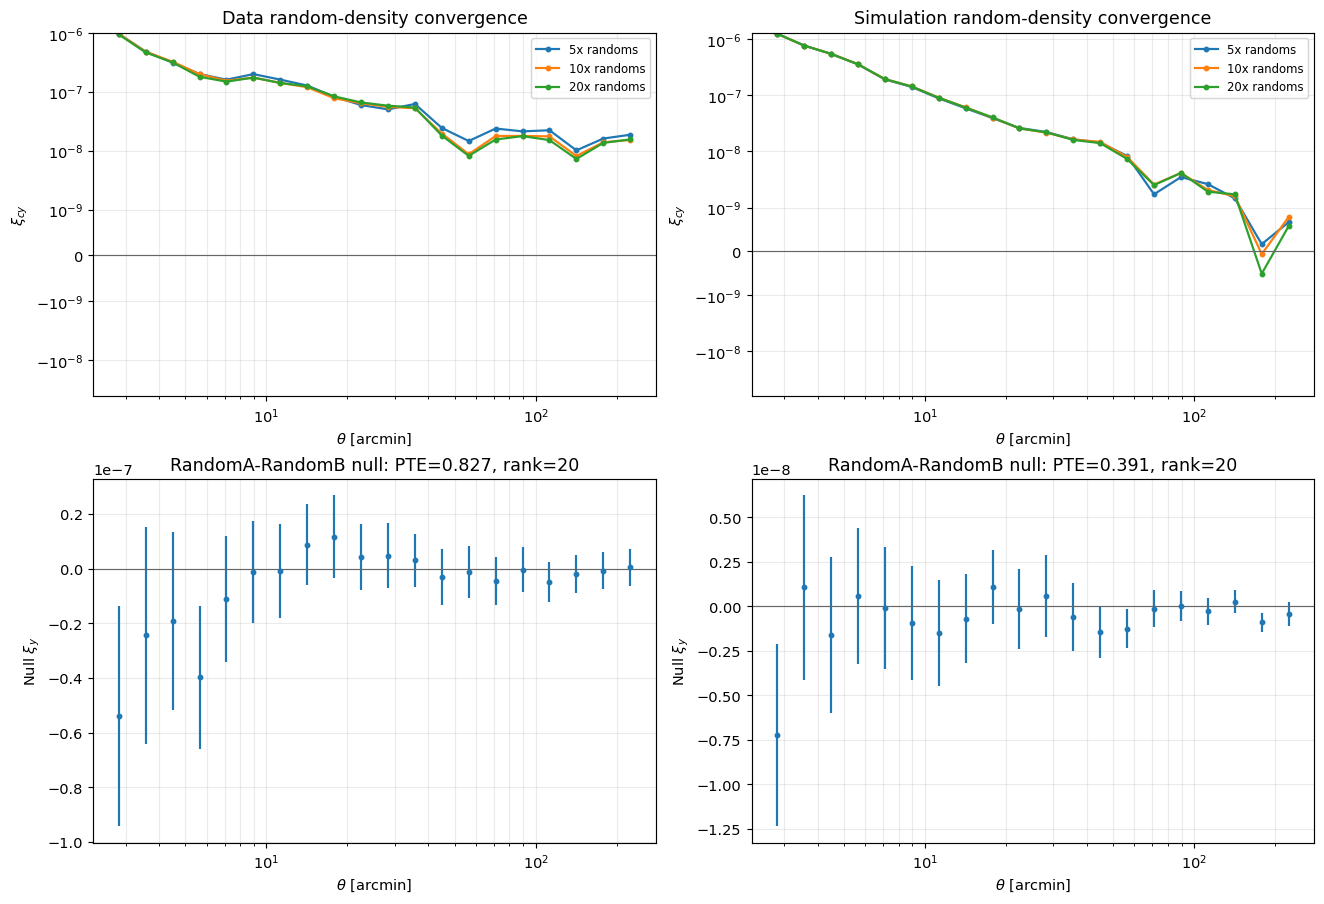

In [2]:
started = time.perf_counter()
analysis = cross.run_analysis(CONFIG)
elapsed_seconds = time.perf_counter() - started
print(json.dumps({**analysis['summary'], 'elapsed_seconds': elapsed_seconds}, indent=2, sort_keys=True))

## Simulation/data comparison and diagnostics

The left panel is the requested cluster-y cross-correlation comparison. The redshift panel makes any residual selection mismatch visible. The diagnostics retain negative bins and show random-density and random-split behavior.

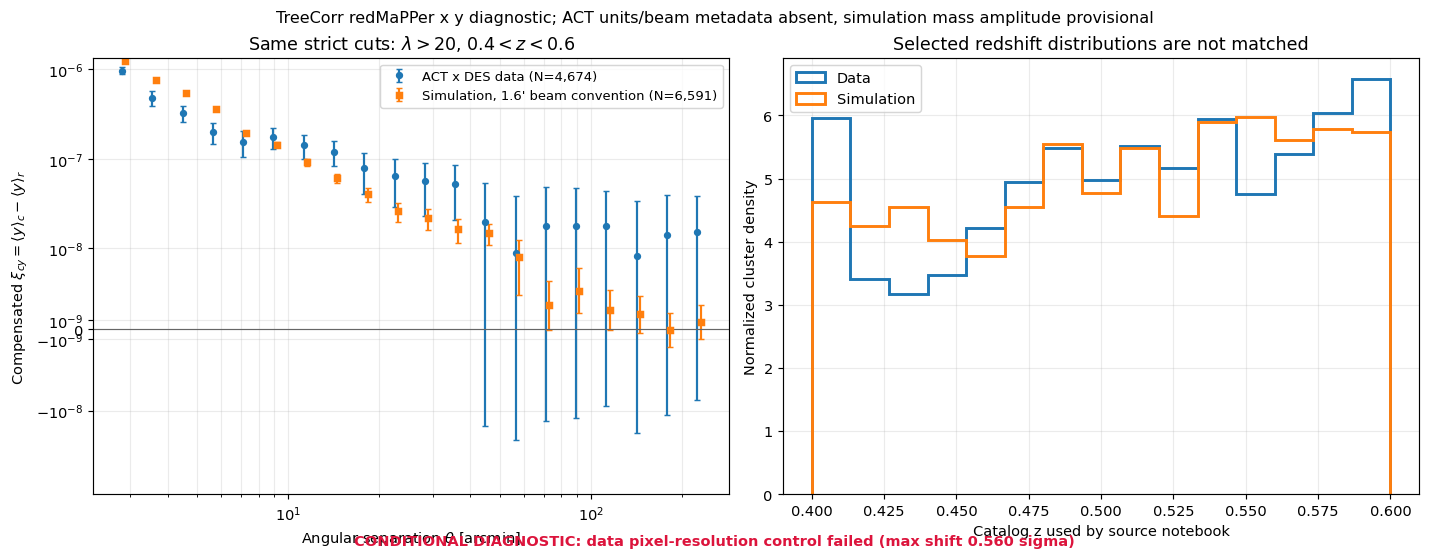

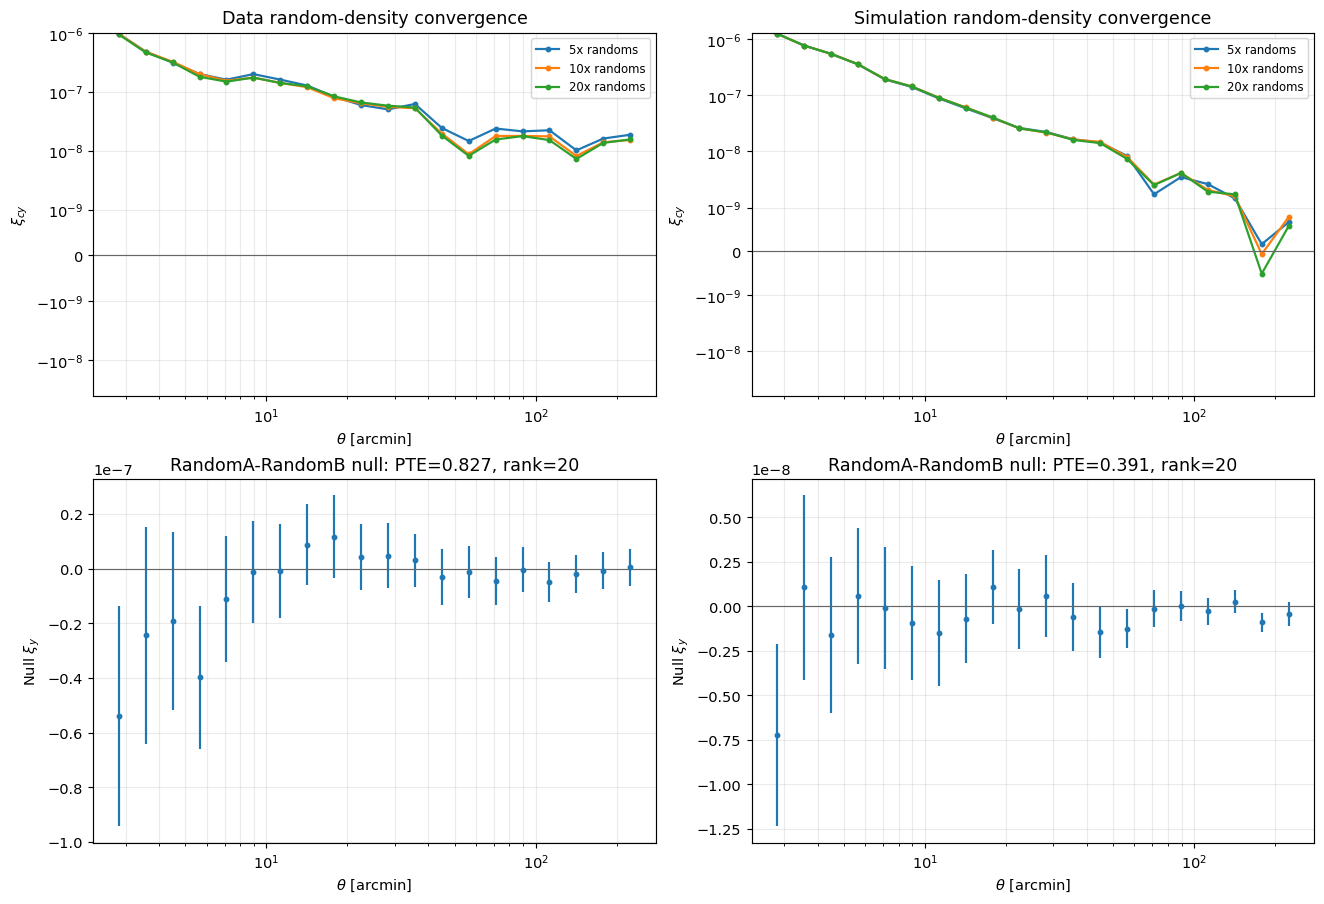

{
  "comparison_png": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_sim_data_comparison_z0p4_0p6.png",
  "diagnostics_png": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_selection_random_diagnostics_z0p4_0p6.png"
}


In [3]:
display(analysis['comparison_figure'])
display(analysis['diagnostics_figure'])
print(json.dumps({'comparison_png': analysis['comparison_path'], 'diagnostics_png': analysis['diagnostics_path']}, indent=2))

## Fail-closed product checks and interpretation boundary

The checks below verify the dynamic selection label, exact source-row identities, finite profiles, the recorded failed data pixel-resolution control, and the separate output path. The comparison is explicitly conditional: the native 0.5-arcmin curve differs from its 1.0-arcmin coarsening by more than the fixed maximum criterion, the ACT file lacks local BUNIT/beam/transfer metadata, simulation random-radius units are geometry-inferred, simulation mass semantics are provisional, catalog weights are intentionally unused to reproduce the source estimator, and the shared simulation map has an unresolved pixel-coarsening refutation documented in the evidence ledger.

In [4]:
summary = analysis['summary']
with h5py.File(summary['result_hdf5'], 'r') as handle:
    saved = {
        'schema': handle.attrs['schema'],
        'selection': handle.attrs['selection'],
        'config_sha256': handle.attrs['config_sha256'],
        'helper_sha256': handle.attrs['helper_sha256'],
        'treecorr_version': handle.attrs['treecorr_version'],
        'input_sha256': json.loads(handle.attrs['input_sha256_json']),
        'cluster_weight_policy': handle.attrs['cluster_weight_policy'],
        'data_transfer_status': handle.attrs['data_transfer_status'],
        'simulation_mass_amplitude_status': handle.attrs['simulation_mass_amplitude_status'],
        'validation_status': handle.attrs['validation_status'],
        'data_resolution_required': bool(handle.attrs['data_resolution_required']),
    }
checks = {
    'selection_label': saved['selection'] == 'lambda > 20 and 0.4 < z < 0.6 (strict; z column)',
    'simulation_pre_mask_identity': analysis['simulation_clusters']['pre_mask_rows'] == 6591 and analysis['simulation_clusters']['pre_mask_row_index_sha256'] == analysis['config']['simulation']['expected_pre_mask_row_index_sha256'],
    'data_pre_mask_identity': analysis['data_clusters']['pre_mask_rows'] == 5441 and analysis['data_clusters']['pre_mask_row_index_sha256'] == analysis['config']['data']['expected_pre_mask_row_index_sha256'],
    'strict_simulation_z': bool(np.all((analysis['simulation_clusters']['redshift'] > 0.4) & (analysis['simulation_clusters']['redshift'] < 0.6))),
    'strict_data_z': bool(np.all((analysis['data_clusters']['redshift'] > 0.4) & (analysis['data_clusters']['redshift'] < 0.6))),
    'finite_profiles': bool(np.isfinite(analysis['simulation']['xi']).all() and np.isfinite(analysis['data']['xi']).all()),
    'positive_central_means': summary['simulation_central_mean'] > 0.0 and summary['data_central_mean'] > 0.0,
    'data_pixel_resolution_failure_recorded': (not summary['data_resolution']['pass']) and summary['validation_status'] == 'refuted_data_resolution' and saved['validation_status'] == 'refuted_data_resolution' and not saved['data_resolution_required'],
    'bounded_randoms': summary['simulation_random_ratio'] in (5, 10, 20) and summary['data_random_ratio'] in (5, 10, 20),
    'input_hashes_unchanged': summary['input_hashes_unchanged'],
}
assert all(checks.values()), checks
print(json.dumps({'checks': checks, 'saved': saved, 'summary': summary}, indent=2, sort_keys=True))

{
  "checks": {
    "bounded_randoms": true,
    "data_pixel_resolution_failure_recorded": true,
    "data_pre_mask_identity": true,
    "finite_profiles": true,
    "input_hashes_unchanged": true,
    "positive_central_means": true,
    "selection_label": true,
    "simulation_pre_mask_identity": true,
    "strict_data_z": true,
    "strict_simulation_z": true
  },
  "saved": {
    "cluster_weight_policy": "unit_weights_to_match_source_notebook_catalog_w_intentionally_unused",
    "config_sha256": "542e9f52d9c906aa3ec01fee325d172644f74fe0d4108b00825cc565704cbf57",
    "data_resolution_required": false,
    "data_transfer_status": "filter_transfer_not_recorded_in_FITS_header",
    "helper_sha256": "92c74c51c859e0aba8257f40615ac32ba1c5e28ad40b34a78ea85b43d42d99a5",
    "input_sha256": {
      "data_cluster": "8ba4319310cb9a1174b3fa50410bcfb3329e37dd5433d0b8748ec5f43b2fff2a",
      "data_mask": "1e4346196a40828ba05d63612026c5184a046c3a42ec4cfb214e44e7fa2be863",
      "data_random": "83e5